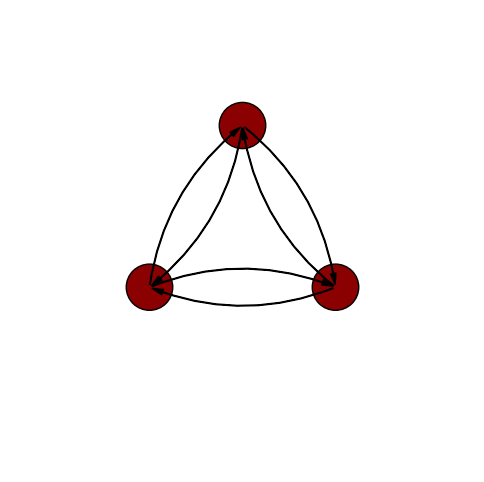

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

ax.axis("off")
c_1 = patches.Circle(xy=[0.5, 0.75], radius=0.05, edgecolor="k", facecolor="darkred")
c_2 = patches.Circle(xy=[0.3, 0.4], radius=0.05, edgecolor="k", facecolor="darkred")
c_3 = patches.Circle(xy=[0.7, 0.4], radius=0.05, edgecolor="k", facecolor="darkred")

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

a_12 = patches.FancyArrowPatch((0.3, 0.4), (0.5, 0.75), connectionstyle="arc3, rad=-.2", **kw)
a_21 = patches.FancyArrowPatch((0.5, 0.75), (0.3, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_23 = patches.FancyArrowPatch((0.5, 0.75), (0.7, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_32 = patches.FancyArrowPatch((0.7, 0.4), (0.5, 0.75), connectionstyle="arc3, rad=-.2", **kw)
a_31 = patches.FancyArrowPatch((0.7, 0.4), (0.3, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_13 = patches.FancyArrowPatch((0.3, 0.4), (0.7, 0.4), connectionstyle="arc3, rad=-.2", **kw)

ax.add_artist(c_1)
ax.add_artist(c_2)
ax.add_artist(c_3)

ax.add_artist(a_12)
ax.add_artist(a_21)
ax.add_artist(a_23)
ax.add_artist(a_32)
ax.add_artist(a_31)
ax.add_artist(a_13)

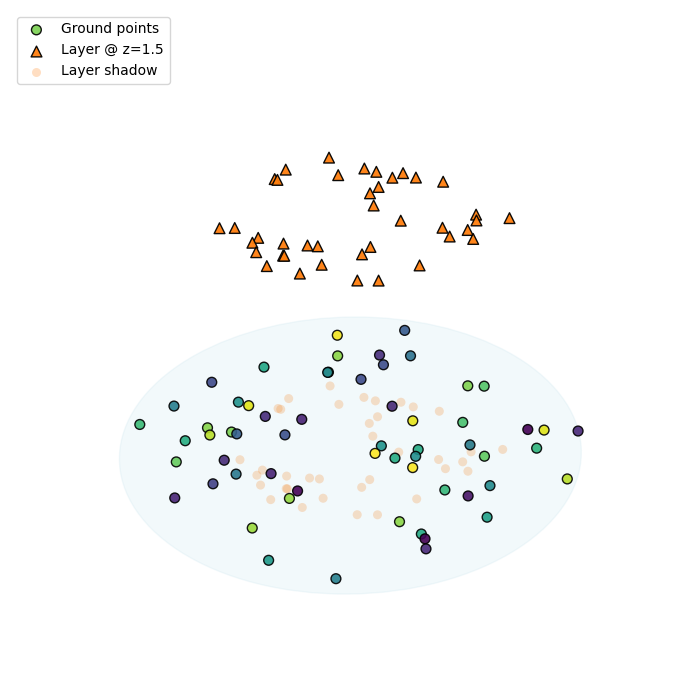

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d import art3d
import numpy as np

def scatter_ground_and_layer(
    x1, y1, x2, y2,
    h=1.0,
    c1=None, c2=None,
    s1=50, s2=60,
    show_shadows=False,
    show_ground_plane=False,
    ground_circle_center=(0.5, 0.5),
    ground_circle_radius=0.6,
    ground_circle_color="lightblue",
    ground_circle_alpha=0.15
):
    """
    Plot two scatters in 3D: one on the ground (z=0) and one at height h.
    Adds an optional circle on the ground plane.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatters
    ax.scatter(x1, y1, z1, c=c1, s=s1, alpha=0.9, edgecolors="k", label="Ground points")
    ax.scatter(x2, y2, z2, c=c2, s=s2, alpha=0.95, edgecolors="k", marker="^", label=f"Layer @ z={h}")

    # Optional: shadows of elevated points on ground
    if show_shadows:
        ax.scatter(
            x2, y2, np.zeros_like(z2),
            c=c2 if isinstance(c2, str) else "k",
            s=s2*0.7, alpha=0.25, marker="o", linewidths=0, label="Layer shadow"
        )

    # Add ground circle at z=0
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        color=ground_circle_color,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # Optional: translucent ground plane
    if show_ground_plane:
        xmin, xmax = np.min([np.min(x1), np.min(x2)]), np.max([np.max(x1), np.max(x2)])
        ymin, ymax = np.min([np.min(y1), np.min(y2)]), np.max([np.max(y1), np.max(y2)])
        Xp, Yp = np.meshgrid(np.linspace(xmin, xmax, 2), np.linspace(ymin, ymax, 2))
        Zp = np.zeros_like(Xp)
        ax.plot_surface(Xp, Yp, Zp, alpha=0.08, rstride=1, cstride=1, linewidth=0)

    # Clean up axes
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=35, azim=135)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# --- Example usage ---
if __name__ == "__main__":
    rng = np.random.default_rng(42)
    x1 = rng.uniform(0, 1, 60)
    y1 = rng.uniform(0, 1, 60)
    x2 = rng.uniform(0.2, 0.8, 40)
    y2 = rng.uniform(0.2, 0.8, 40)
    colors1 = rng.random(60)
    colors2 = "tab:orange"

    scatter_ground_and_layer(
        x1, y1, x2, y2,
        h=1.5,
        c1=colors1, c2=colors2,
        show_shadows=True,
        show_ground_plane=False,
        ground_circle_center=(0.5, 0.5),
        ground_circle_radius=0.6,
        ground_circle_color="lightblue",
        ground_circle_alpha=0.15
    )


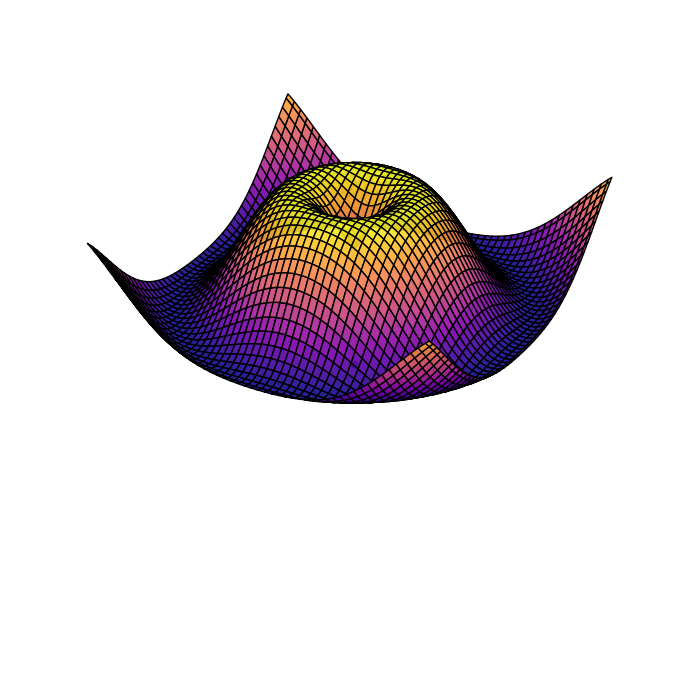

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Create figure and 3D axes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot 2D heatmap on the ground
ground = ax.scatter(0, 0)

# 2. Plot 3D surface above the ground
surf = ax.plot_surface(X, Y, Z + 2, cmap='plasma', edgecolor='k', alpha=0.9)

# 3. Disable grid, ticks, and axes
ax.grid(False)                 # Disable grid
ax.set_axis_off()              # Hide axes completely
ax.xaxis.set_visible(False)    # Hide x-axis
ax.yaxis.set_visible(False)    # Hide y-axis
ax.zaxis.set_visible(False)    # Hide z-axis

# Set limits so the figure looks balanced
ax.set_zlim(-2, 3)

plt.tight_layout()
plt.show()
